In [66]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import numpy as np
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

df = pd.read_csv("genres.csv", sep=",", parse_dates=['endTime'])
weather_data = pd.read_csv("vancouverWeather.csv",sep=",", parse_dates=['datetime'])

In [67]:
df = pd.read_csv("genres.csv", sep=",", parse_dates=['endTime'])

# get rid of all nan + seen live values
df = df.dropna()
#print(f"count: {df.shape[0]}") about 300 n/a dropped
df = df[df['genre'] != 'seen live']
#print(f"count: {df.shape[0]}")  about 400 seen live dropped
df["genre"] = df['genre'].str.lower()
#separate out unique genres
genres = df['genre'].unique()

#converts text features to numbers based on frequency
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(genres)

#kmeans clustering
num_clusters = 30
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(X)

genre_clusters = {i: [] for i in range(num_clusters)}
for idx, label in enumerate(kmeans.labels_):
    genre_clusters[label].append(genres[idx])

cluster_titles = {}
for cluster, genres_in_cluster in genre_clusters.items():
    # get the most frequent genre in the cluster as the title
    cluster_titles[cluster] = max(set(genres_in_cluster), key=genres_in_cluster.count)

# for cluster, genres_in_cluster in genre_clusters.items():
#     print(f"Cluster: {cluster_titles[cluster].capitalize()}")
#     print(" → " + ", ".join(genres_in_cluster))
#     print()

#create a dictionary mapping genre to cluster
genre_to_cluster = {genre: label for genre, label in zip(genres, kmeans.labels_)}

#add cluster to original df
df['cluster'] = df['genre'].map(genre_to_cluster)


In [68]:
df.rename(columns={'endTime':'timestamp'}, inplace=True)
weather_data.rename(columns={'datetime':'timestamp'}, inplace=True)
df['timestamp'] = df['timestamp'].dt.round('h')
weather_data['timestamp'] = weather_data['timestamp'].dt.round('h')

In [69]:
merged_data = pd.merge(df, weather_data, on='timestamp', how='inner')

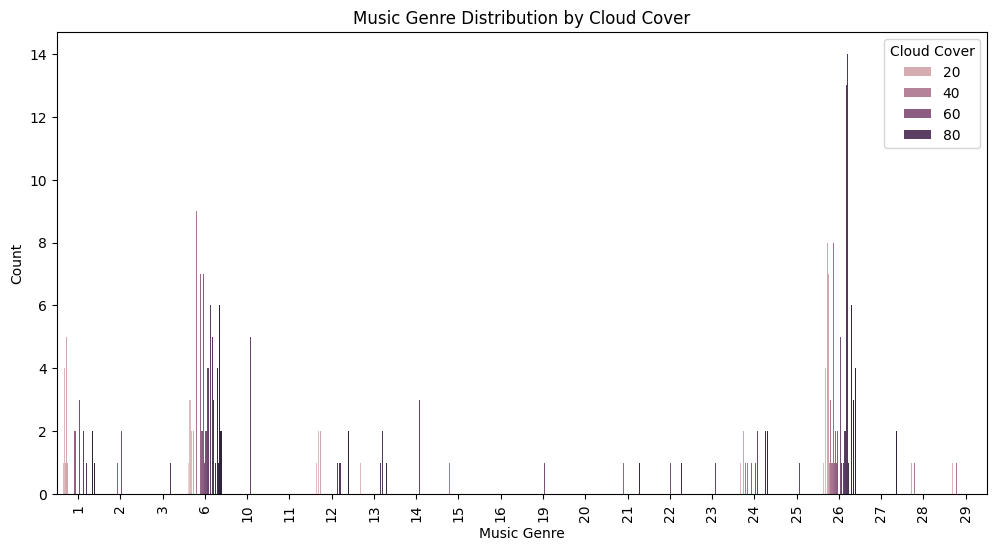

In [70]:
plt.figure(figsize=(12, 6))
sns.countplot(data=merged_data, x='cluster', hue='cloudcover')
plt.title("Music Genre Distribution by Cloud Cover")
plt.xticks(rotation=90)
plt.xlabel("Music Genre")
plt.ylabel("Count")
plt.legend(title="Cloud Cover")
plt.show()

In [71]:
contingency_table = pd.crosstab(merged_data['cloudcover'], merged_data['cluster'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Test Statistic: {chi2:.3f}")
print(p)

if p < 0.05:
    print("There is a significant relationship between Cloud Cover and Music Genre.")
else:
    print("No significant relationship found between Cloud and Music Genre.")

Chi-Square Test Statistic: 1646.625
2.1263777681961425e-23
There is a significant relationship between Cloud Cover and Music Genre.


In [72]:
X = merged_data[['cluster']]
y = merged_data['cloudcover']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [82]:
dt_model = DecisionTreeRegressor(max_depth=30, min_samples_split=3, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [83]:
r2 = r2_score(y_test, dt_pred)
print(f"R² Score: {r2}")

R² Score: 0.026080889056093515
